In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 20)
RANDOM_STATE = 42

In [2]:
df = pd.read_csv('../data/wholesale_customers.csv')
print(df.shape)
df.describe()

(440, 8)


,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
count,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000
mean,1.322727,2.543182,12000.297727,5796.265909,7951.277273,3071.931818,2881.493182,1524.870455
std,0.468052,0.774272,12647.328865,7380.377175,9503.162829,4854.673333,4767.854448,2820.105937
min,1.000000,1.000000,3.000000,55.000000,3.000000,25.000000,3.000000,3.000000
25%,1.000000,2.000000,3127.750000,1533.000000,2153.000000,742.250000,256.750000,408.250000
50%,1.000000,3.000000,8504.000000,3627.000000,4755.500000,1526.000000,816.500000,965.500000
75%,2.000000,3.000000,16933.750000,7190.250000,10655.750000,3554.250000,3922.000000,1820.250000
max,2.000000,3.000000,112151.000000,73498.000000,92780.000000,60869.000000,40827.000000,47943.000000


In [3]:
from scipy.stats import skew

SPENDING_COLS = ['Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen']

skewness = df[SPENDING_COLS].apply(lambda x: skew(x))
skewness.sort_values(ascending=False)

Delicassen          11.113534
Frozen               5.887826
Milk                 4.039922
Detergents_Paper     3.619458
Grocery              3.575187
Fresh                2.552583
dtype: float64

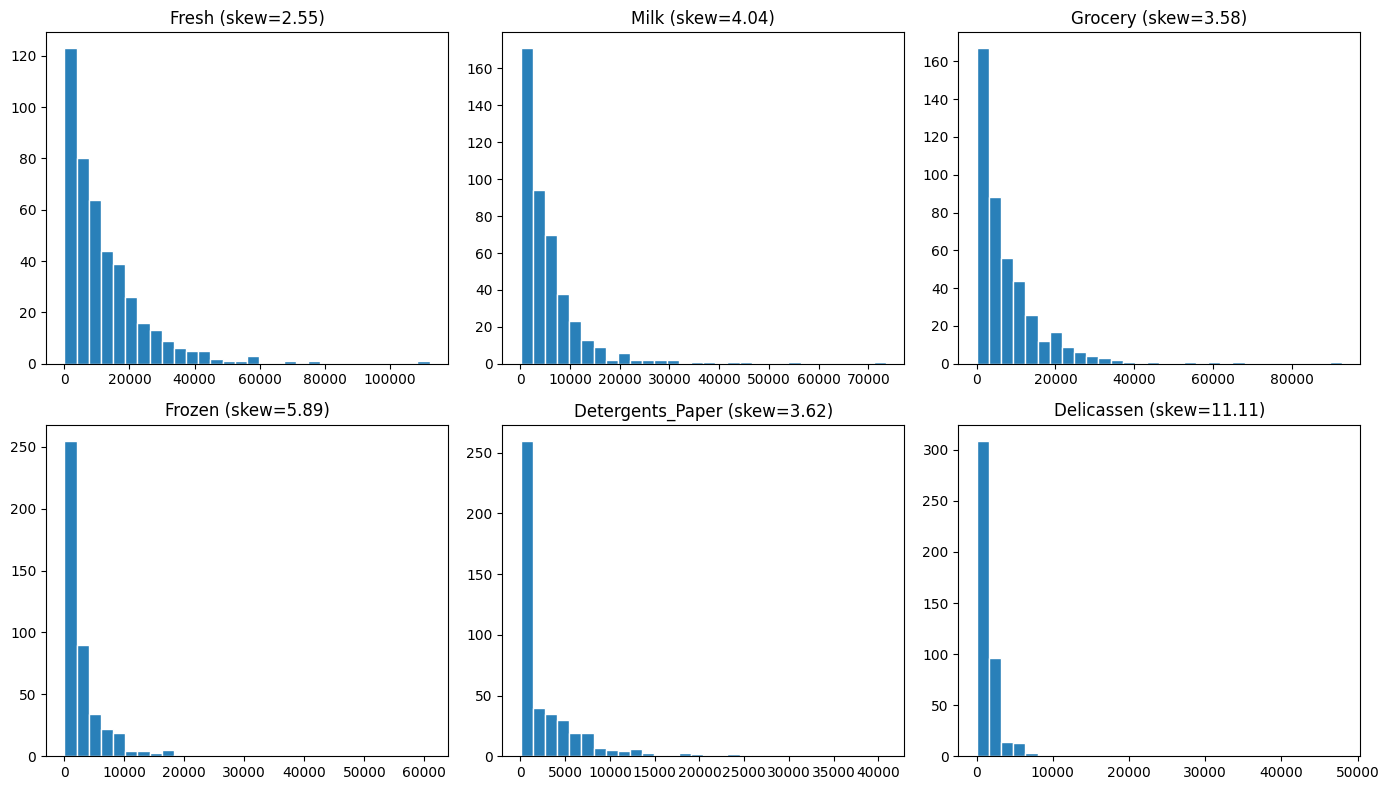

In [4]:
import os
os.makedirs('../assets', exist_ok=True)

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()
for i, col in enumerate(SPENDING_COLS):
    axes[i].hist(df[col], bins=30, color='#2980b9', edgecolor='white')
    axes[i].set_title(f'{col} (skew={skewness[col]:.2f})')
plt.tight_layout()
plt.savefig('../assets/01_raw_distributions_skew.png')
plt.show()

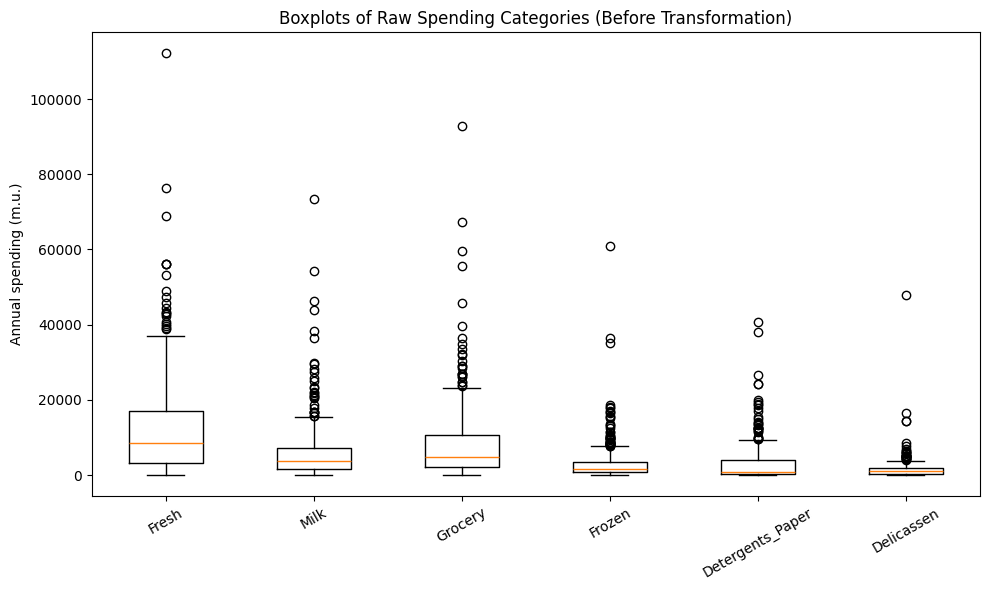

In [5]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.boxplot([df[col] for col in SPENDING_COLS], tick_labels=SPENDING_COLS)
ax.set_title('Boxplots of Raw Spending Categories (Before Transformation)')
ax.set_ylabel('Annual spending (m.u.)')
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('../assets/02_raw_boxplots_outliers.png')
plt.show()

In [6]:
CLUSTER_FEATURES = SPENDING_COLS  # Fresh, Milk, Grocery, Frozen, Detergents_Paper, Delicassen
VALIDATION_FEATURES = ['Channel', 'Region']

print("Features used for clustering:", CLUSTER_FEATURES)
print("Features held out for validation:", VALIDATION_FEATURES)

# Quick look at how Channel/Region relate to raw spending, just for context
df.groupby('Channel')[SPENDING_COLS].mean().round(1)

Features used for clustering: ['Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen']
Features held out for validation: ['Channel', 'Region']


,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
Channel,,,,,,
1,13475.6,3451.7,3962.1,3748.3,790.6,1416.0
2,8904.3,10716.5,16322.9,1652.6,7269.5,1753.4


In [7]:
df_log = df.copy()
for col in SPENDING_COLS:
    df_log[col] = np.log1p(df_log[col])

skewness_after = df_log[SPENDING_COLS].apply(lambda x: skew(x))

comparison = pd.DataFrame({'Before (raw)': skewness, 'After (log1p)': skewness_after})
comparison.round(3)

,Before (raw),After (log1p)
Fresh,2.553,-1.570
Milk,4.040,-0.223
Grocery,3.575,-0.673
Frozen,5.888,-0.351
Detergents_Paper,3.619,-0.235
Delicassen,11.114,-1.088


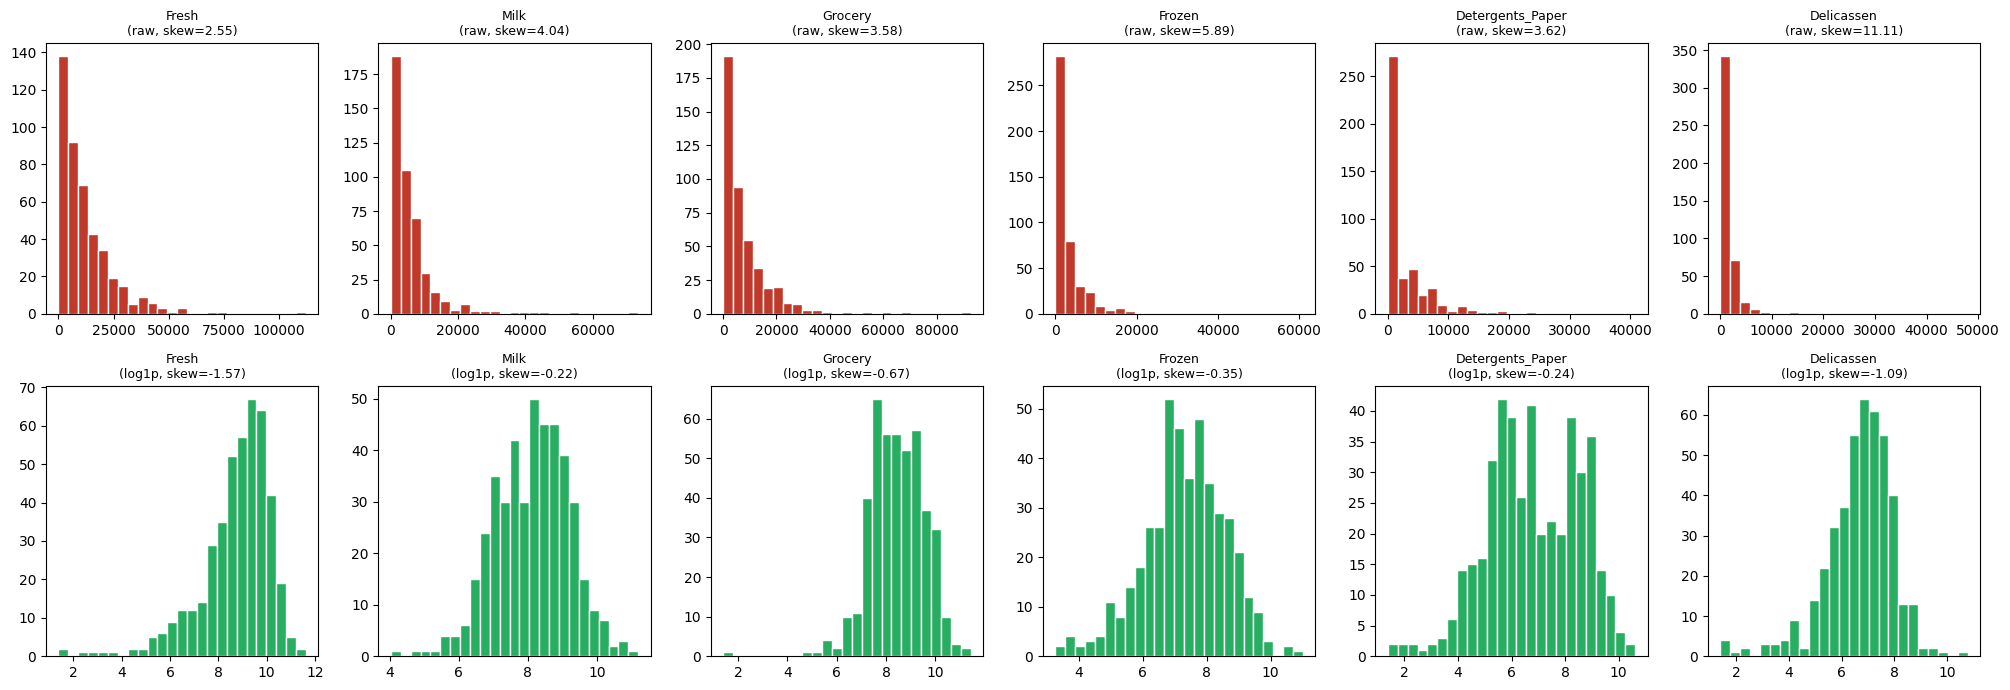

In [8]:
fig, axes = plt.subplots(2, 6, figsize=(20, 7))
for i, col in enumerate(SPENDING_COLS):
    axes[0, i].hist(df[col], bins=25, color='#c0392b', edgecolor='white')
    axes[0, i].set_title(f'{col}\n(raw, skew={skewness[col]:.2f})', fontsize=9)
    axes[1, i].hist(df_log[col], bins=25, color='#27ae60', edgecolor='white')
    axes[1, i].set_title(f'{col}\n(log1p, skew={skewness_after[col]:.2f})', fontsize=9)
plt.tight_layout()
plt.savefig('../assets/03_before_after_log_transform.png')
plt.show()

In [9]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_log[SPENDING_COLS])
X_scaled = pd.DataFrame(X_scaled, columns=SPENDING_COLS)

X_scaled.describe().round(2)

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
count,440.00,440.00,440.00,440.00,440.00,440.00
mean,0.00,-0.00,-0.00,0.00,-0.00,-0.00
std,1.00,1.00,1.00,1.00,1.00,1.00
min,-5.00,-3.79,-6.36,-3.16,-3.17,-4.09
25%,-0.47,-0.73,-0.69,-0.54,-0.73,-0.51
50%,0.21,0.07,0.02,0.02,-0.05,0.16
75%,0.68,0.70,0.75,0.68,0.87,0.65
max,1.97,2.86,2.70,2.90,2.24,3.18


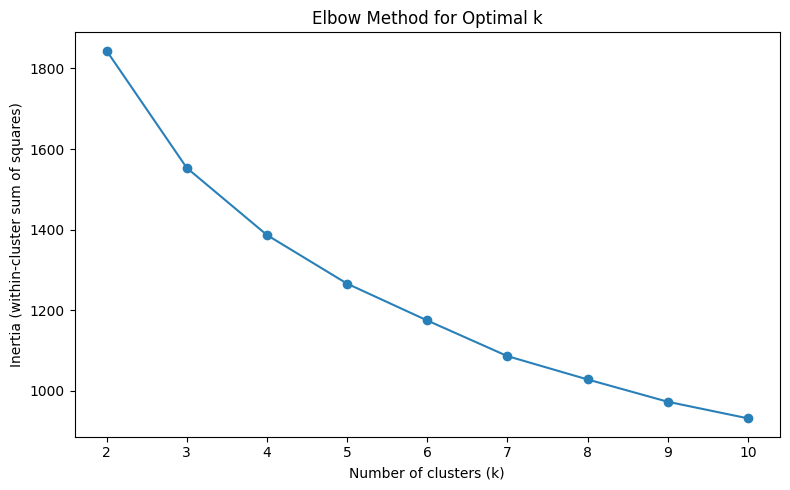

In [10]:
from sklearn.cluster import KMeans

inertias = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(list(k_range), inertias, marker='o', color='#2980b9')
ax.set_xlabel('Number of clusters (k)')
ax.set_ylabel('Inertia (within-cluster sum of squares)')
ax.set_title('Elbow Method for Optimal k')
ax.set_xticks(list(k_range))
plt.tight_layout()
plt.savefig('../assets/04_elbow_method.png')
plt.show()

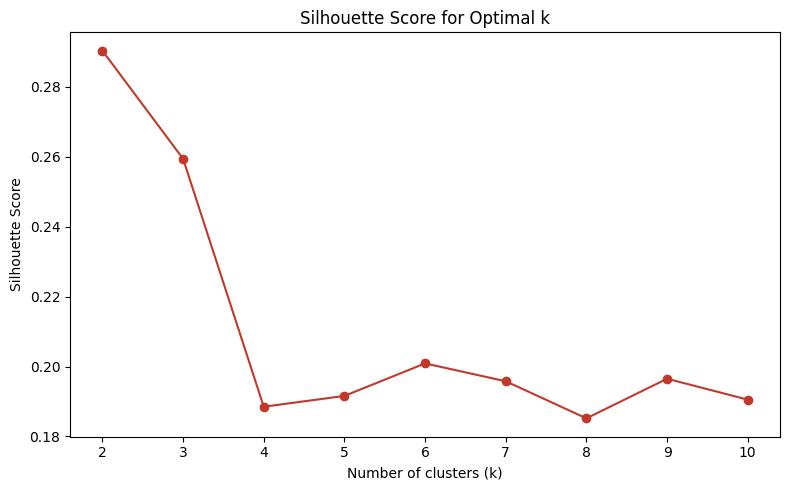

k=2: silhouette=0.2903
k=3: silhouette=0.2594
k=4: silhouette=0.1885
k=5: silhouette=0.1916
k=6: silhouette=0.2009
k=7: silhouette=0.1958
k=8: silhouette=0.1852
k=9: silhouette=0.1965
k=10: silhouette=0.1905


In [11]:
from sklearn.metrics import silhouette_score

silhouette_scores = []
for k in k_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(list(k_range), silhouette_scores, marker='o', color='#c0392b')
ax.set_xlabel('Number of clusters (k)')
ax.set_ylabel('Silhouette Score')
ax.set_title('Silhouette Score for Optimal k')
ax.set_xticks(list(k_range))
plt.tight_layout()
plt.savefig('../assets/05_silhouette_scores.png')
plt.show()

for k, s in zip(k_range, silhouette_scores):
    print(f"k={k}: silhouette={s:.4f}")

In [12]:
CHOSEN_K = 3
print(f"Chosen k = {CHOSEN_K}")
print(f"Rationale: second-highest silhouette score ({silhouette_scores[1]:.3f}) after k=2 ({silhouette_scores[0]:.3f}),")
print("but avoids trivially rediscovering the binary Channel split, and provides richer business segments.")

Chosen k = 3
Rationale: second-highest silhouette score (0.259) after k=2 (0.290),
but avoids trivially rediscovering the binary Channel split, and provides richer business segments.


In [13]:
kmeans_final = KMeans(n_clusters=CHOSEN_K, random_state=RANDOM_STATE, n_init=10)
kmeans_labels = kmeans_final.fit_predict(X_scaled)

df['kmeans_cluster'] = kmeans_labels
print(pd.Series(kmeans_labels).value_counts().sort_index())

0     80
1    147
2    213
Name: count, dtype: int64


In [14]:
from sklearn.cluster import AgglomerativeClustering

agglo = AgglomerativeClustering(n_clusters=CHOSEN_K, linkage='ward')
agglo_labels = agglo.fit_predict(X_scaled)

df['agglo_cluster'] = agglo_labels
print(pd.Series(agglo_labels).value_counts().sort_index())

0    262
1     53
2    125
Name: count, dtype: int64


In [15]:
from sklearn.metrics import silhouette_score

kmeans_sil = silhouette_score(X_scaled, kmeans_labels)
agglo_sil = silhouette_score(X_scaled, agglo_labels)

print(f"K-Means silhouette (k={CHOSEN_K}): {kmeans_sil:.4f}")
print(f"Agglomerative silhouette (k={CHOSEN_K}): {agglo_sil:.4f}")

# Cross-tabulate to see how much the two methods agree
comparison_ct = pd.crosstab(df['kmeans_cluster'], df['agglo_cluster'])
comparison_ct

K-Means silhouette (k=3): 0.2594
Agglomerative silhouette (k=3): 0.2547


agglo_cluster,0,1,2
kmeans_cluster,,,
0,10,36,34
1,50,6,91
2,202,11,0


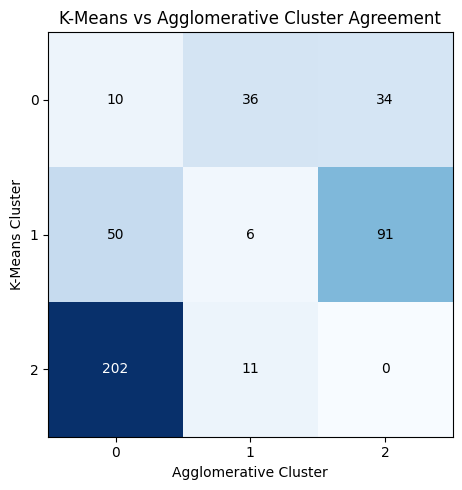

In [16]:
fig, ax = plt.subplots(figsize=(6.5, 5))
im = ax.imshow(comparison_ct.values, cmap='Blues')
for i in range(comparison_ct.shape[0]):
    for j in range(comparison_ct.shape[1]):
        ax.text(j, i, comparison_ct.values[i,j], ha='center', va='center',
                color='white' if comparison_ct.values[i,j] > 100 else 'black')
ax.set_xticks(range(comparison_ct.shape[1])); ax.set_yticks(range(comparison_ct.shape[0]))
ax.set_xlabel('Agglomerative Cluster'); ax.set_ylabel('K-Means Cluster')
ax.set_title('K-Means vs Agglomerative Cluster Agreement')
plt.tight_layout()
plt.savefig('../assets/06_algorithm_comparison.png')
plt.show()

In [17]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

explained_var = pca.explained_variance_ratio_
print(f"PC1 explains {explained_var[0]*100:.1f}% of variance")
print(f"PC2 explains {explained_var[1]*100:.1f}% of variance")
print(f"Total explained by 2D: {explained_var.sum()*100:.1f}%")


PC1 explains 44.1% of variance
PC2 explains 27.2% of variance
Total explained by 2D: 71.3%


C:\Users\darsh\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


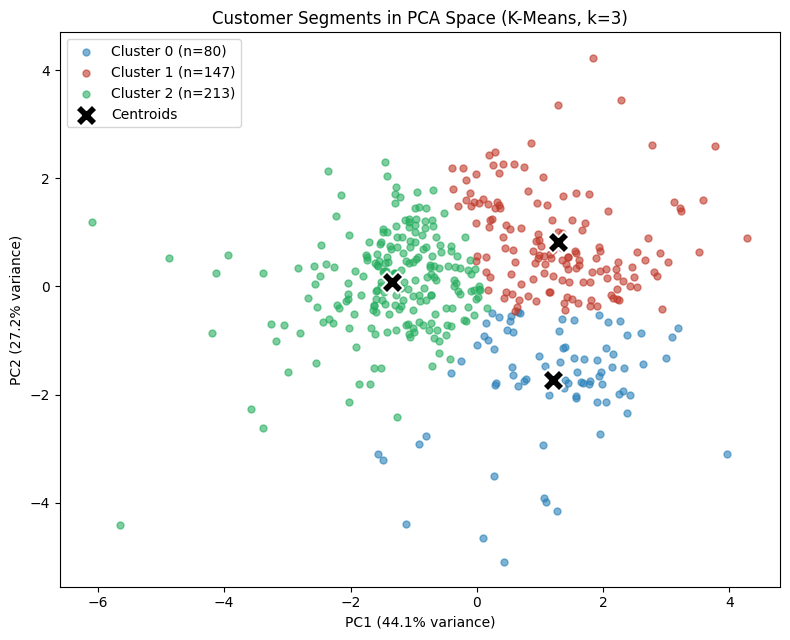

In [18]:
fig, ax = plt.subplots(figsize=(8, 6.5))
colors_map = ['#2980b9', '#c0392b', '#27ae60']
for cluster_id in range(CHOSEN_K):
    mask = kmeans_labels == cluster_id
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1], s=25, alpha=0.6,
               color=colors_map[cluster_id], label=f'Cluster {cluster_id} (n={mask.sum()})')

# Plot centroids too, projected into PCA space
centroids_pca = pca.transform(kmeans_final.cluster_centers_)
ax.scatter(centroids_pca[:, 0], centroids_pca[:, 1], s=250, marker='X',
           color='black', edgecolor='white', linewidth=1.5, label='Centroids', zorder=5)

ax.set_xlabel(f'PC1 ({explained_var[0]*100:.1f}% variance)')
ax.set_ylabel(f'PC2 ({explained_var[1]*100:.1f}% variance)')
ax.set_title(f'Customer Segments in PCA Space (K-Means, k={CHOSEN_K})')
ax.legend()
plt.tight_layout()
plt.savefig('../assets/07_pca_cluster_visualization.png')
plt.show()

In [20]:
df['profile_cluster'] = kmeans_labels

counts = df['profile_cluster'].value_counts().sort_index()
print(counts)

profile = df.groupby('profile_cluster')[SPENDING_COLS].agg(['mean', 'median']).round(1)
profile

profile_cluster
0     80
1    147
2    213
Name: count, dtype: int64


Fresh              Milk          Grocery           Frozen  \
                    mean   median     mean  median     mean   median    mean   
profile_cluster                                                                
0                 2898.6   1492.5   7135.9  6300.5  12569.7  10502.5   606.6   
1                17042.8  12126.0  10559.7  7184.0  13333.6   9965.0  4133.1   
2                11938.7   9612.0   2005.7  1601.0   2502.1   2155.0  3265.5   

                        Detergents_Paper         Delicassen          
                 median             mean  median       mean  median  
profile_cluster                                                      
0                 376.0           5554.4  4217.5      782.9   434.5  
1                2005.0           4987.0  3378.0     2846.6  2005.0  
2                2121.0            424.5   274.0      891.4   686.0

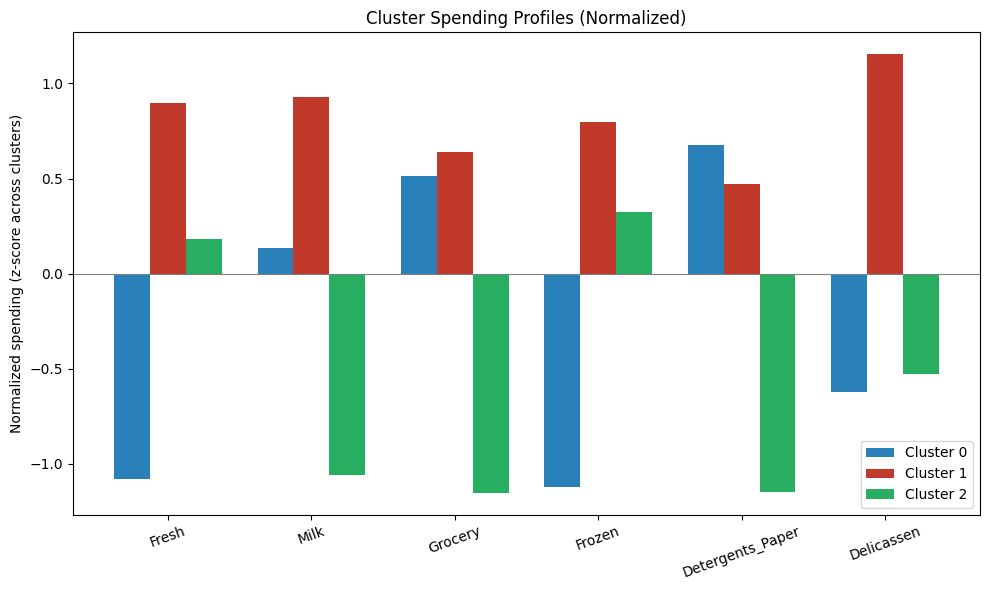

In [21]:
cluster_means = df.groupby('profile_cluster')[SPENDING_COLS].mean()
cluster_means_norm = (cluster_means - cluster_means.mean()) / cluster_means.std()

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(SPENDING_COLS))
width = 0.25
colors_map = ['#2980b9', '#c0392b', '#27ae60']
for i in range(CHOSEN_K):
    ax.bar(x + i*width, cluster_means_norm.loc[i], width, label=f'Cluster {i}', color=colors_map[i])
ax.set_xticks(x + width)
ax.set_xticklabels(SPENDING_COLS, rotation=20)
ax.set_ylabel('Normalized spending (z-score across clusters)')
ax.set_title('Cluster Spending Profiles (Normalized)')
ax.axhline(0, color='gray', linewidth=0.8)
ax.legend()
plt.tight_layout()
plt.show()